# 05 · Prediction model for pain no-worsening (DBS and pooled)

**Problem:** predict `no_worsening` (Δ NP1PAIN < +1 from [−12,0] → [+6,+18]) from baseline features.

**Models:** elastic-net logistic, random forest, XGBoost. **Evaluation:** leave-one-out CV (small n), report AUC + Brier + calibration. Variable importance via permutation.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2)
  library(glmnet); library(randomForest); library(xgboost); library(pROC)
})

dat <- readRDS(file.path(OUT_OBJ, "baseline_and_delta.rds"))

# Feature matrix — simple imputation by median for small missingness
feat_cols <- c("age_at_visit","ageonset","duration_yrs","SEX","BMI",
               "LEDD","updrs3_score","NHY","NP1PAIN","NP1DPRS","NP1ANXS",
               "gds","stai","scopa")
median_impute <- function(x) { x[is.na(x)] <- stats::median(x, na.rm = TRUE); x }
X <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(dbs, dplyr::all_of(feat_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute)) %>%
  as.matrix()
y <- dat$no_worsening
cat("Design matrix:", nrow(X), "x", ncol(X), "  prevalence(no_worsening) =", mean(y), "\n")

Design matrix: 74 x 15   prevalence(no_worsening) = 0.7702703 


In [2]:
# Leave-one-out CV predictions for three models
loo_predict <- function(fit_fn) {
  n <- nrow(X); preds <- numeric(n)
  for (i in seq_len(n)) {
    preds[i] <- fit_fn(X[-i, , drop = FALSE], y[-i], X[i, , drop = FALSE])
  }
  preds
}

# 1) Elastic-net (alpha=0.5) with lambda picked by inner CV on the training fold
fit_enet <- function(Xtr, ytr, Xte) {
  cv <- glmnet::cv.glmnet(Xtr, ytr, family = "binomial", alpha = 0.5, nfolds = 5)
  p <- predict(cv, newx = Xte, s = "lambda.min", type = "response")
  as.numeric(p)
}
set.seed(42); pred_enet <- loo_predict(fit_enet)

# 2) Random forest
fit_rf <- function(Xtr, ytr, Xte) {
  m <- randomForest::randomForest(x = Xtr, y = factor(ytr, levels = c(0,1)),
                                  ntree = 500, nodesize = 5, importance = FALSE)
  as.numeric(predict(m, newdata = Xte, type = "prob")[, "1"])
}
set.seed(42); pred_rf <- loo_predict(fit_rf)

# 3) XGBoost
fit_xgb <- function(Xtr, ytr, Xte) {
  dtr <- xgboost::xgb.DMatrix(Xtr, label = ytr)
  m <- xgboost::xgb.train(
    params = list(objective = "binary:logistic", eta = 0.05, max_depth = 3,
                  subsample = 0.8, colsample_bytree = 0.8,
                  eval_metric = "logloss", verbosity = 0),
    data = dtr, nrounds = 200, verbose = 0
  )
  as.numeric(predict(m, Xte))
}
set.seed(42); pred_xgb <- loo_predict(fit_xgb)

cat("Predictions computed for all three models.\n")

Predictions computed for all three models.


In [3]:
metrics <- function(name, p, y) {
  auc <- suppressMessages(as.numeric(pROC::auc(pROC::roc(y, p, quiet = TRUE))))
  brier <- mean((p - y)^2)
  tibble::tibble(model = name, AUC = auc, Brier = brier)
}
res <- dplyr::bind_rows(
  metrics("Elastic Net", pred_enet, y),
  metrics("Random Forest", pred_rf, y),
  metrics("XGBoost", pred_xgb, y),
  metrics("Naive (prevalence)", rep(mean(y), length(y)), y)
)
print(res)
save_table(res, "prediction_model_metrics")

# A tibble: 4 × 3
  model                AUC Brier
  <chr>              <dbl> <dbl>
1 Elastic Net        0.602 0.193
2 Random Forest      0.510 0.190
3 XGBoost            0.609 0.197
4 Naive (prevalence) 0.5   0.177


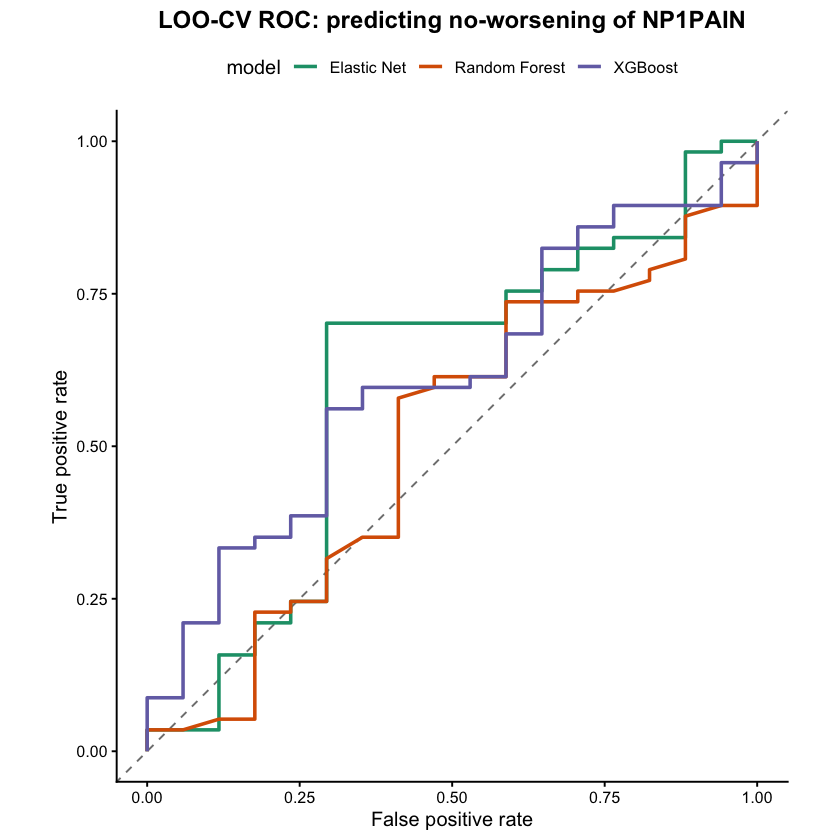

In [4]:
# ROC overlay
roc_df <- purrr::map_dfr(
  list(`Elastic Net` = pred_enet, `Random Forest` = pred_rf, XGBoost = pred_xgb),
  function(p) {
    r <- pROC::roc(y, p, quiet = TRUE)
    tibble::tibble(fpr = 1 - r$specificities, tpr = r$sensitivities)
  }, .id = "model")

p_roc <- ggplot(roc_df, aes(x = fpr, y = tpr, colour = model)) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", colour = "grey50") +
  geom_path(linewidth = 1) +
  scale_colour_brewer(palette = "Dark2") +
  coord_equal() +
  labs(title = "LOO-CV ROC: predicting no-worsening of NP1PAIN",
       x = "False positive rate", y = "True positive rate") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "top")
p_roc
save_fig(p_roc, "Fig11_prediction_roc", width = 5.5, height = 5.5)

# A tibble: 15 × 5
   feature         `0`     `1` MeanDecreaseAccuracy MeanDecreaseGini
   <chr>         <dbl>   <dbl>                <dbl>            <dbl>
 1 ageonset     -2.21   1.62                 0.471             3.28 
 2 age_at_visit  1.70   3.89                 4.24              3.14 
 3 BMI           4.76   1.94                 3.82              2.86 
 4 duration_yrs -1.50   0.312               -0.420             2.31 
 5 stai          0.350 -0.226                0.0370            2.03 
 6 updrs3_score -0.694  2.53                 1.62              2.01 
 7 scopa        -2.07   1.50                -0.222             1.79 
 8 NP1PAIN      -2.97   3.71                 1.95              1.52 
 9 gds           0.952  4.69                 4.13              1.48 
10 dbs           1.69   4.12                 4.20              1.21 
11 LEDD          0.147  2.67                 2.18              1.14 
12 NP1DPRS       0.720  3.11                 2.67              0.962
13 NP1ANXS     

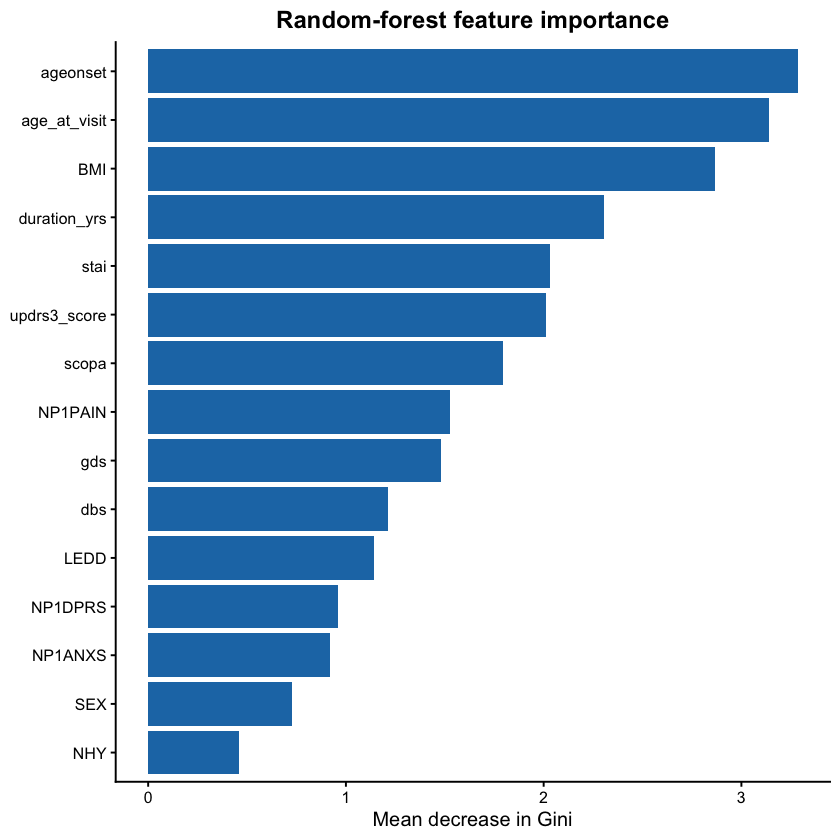

In [5]:
# Feature importance (random forest, trained on full data)
set.seed(42)
rf_full <- randomForest::randomForest(
  x = X, y = factor(y, levels = c(0,1)),
  ntree = 1000, importance = TRUE
)
imp <- randomForest::importance(rf_full)
imp_df <- tibble::as_tibble(imp, rownames = "feature") %>%
  dplyr::arrange(dplyr::desc(MeanDecreaseGini))
print(imp_df)
save_table(imp_df, "rf_importance")

p_imp <- ggplot(imp_df %>% dplyr::mutate(feature = forcats::fct_reorder(feature, MeanDecreaseGini)),
                aes(x = MeanDecreaseGini, y = feature)) +
  geom_col(fill = "#1f78b4") +
  labs(title = "Random-forest feature importance",
       x = "Mean decrease in Gini", y = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_imp
save_fig(p_imp, "Fig12_rf_importance", width = 6.5, height = 5)